# 第034讲 随机与小批量梯度下降
同一四行目标，完整更新链、精确枚举、公平成本和多条随机流。先读实验指南；从第一格顺序执行。

In [1]:
from pathlib import Path
import hashlib, json, sys
ROOT = Path.cwd()
if not (ROOT / 'experiment.py').is_file():
    raise ValueError('请从本单元目录启动Notebook')
BASELINE = {'data/labels.csv': '96816e82f86790a22399460c6e19ca3612cb4c9bf12868aabef97478dc660149', 'data/model_spec.json': 'f10668340fcec2093cd275aed1676f98a267b688428be898f784bf9e095b3d59'}
for name, expected in BASELINE.items():
    if hashlib.sha256((ROOT / name).read_bytes()).hexdigest() != expected:
        raise ValueError('默认输入已改变；固定说明不再适用：' + name)
sys.path.insert(0, str(ROOT))
import experiment as ex
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction as F
from IPython.display import display, Image
import io
def show(fig):
    buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=130,bbox_inches='tight'); display(Image(data=buf.getvalue()))
y, spec = ex.load_inputs()
print('Python', sys.version.split()[0], 'NumPy', np.__version__)
print('完整默认输入校验通过；数据行数', len(y))

Python 3.12.14 NumPy 2.3.5
完整默认输入校验通过；数据行数 4


## 1 独立手算每一行
下面不调用求解器，用Fraction从旧参数、全部预测/残差，到选中局部导数与更新，再做下一轮完整前向。

In [2]:
w = F(0); eta = F(1,4); fy = [F(-2), F(0), F(1), F(5)]
paper_states = []
for t in range(3):
    residuals = [w-v for v in fy]
    full_loss = sum(r*r/2 for r in residuals)/4
    paper_states.append((w, full_loss))
    print('state', t, 'w', w, 'prediction', [str(w)]*4, 'residual', list(map(str,residuals)))
    print('half squares', [str(r*r/2) for r in residuals], 'gradient contributions', [str(r/4) for r in residuals], 'F', full_loss)
    if t < 2:
        index = [3,0][t]; r = residuals[index]; g = r*1*1
        print('selected', index+1, 'local chain', str(r), '* 1 * 1', 'gradient', str(g), 'new w', str(w-eta*g))
        w = w-eta*g
hand = ex.hand_chain(y, spec)
assert [(str(w),str(f)) for w,f in paper_states] == [(s['parameter'],s['loss']) for s in hand['states']]

state 0 w 0 prediction ['0', '0', '0', '0'] residual ['2', '0', '-1', '-5']
half squares ['2', '0', '1/2', '25/2'] gradient contributions ['1/2', '0', '-1/4', '-5/4'] F 15/4
selected 4 local chain -5 * 1 * 1 gradient -5 new w 5/4
state 1 w 5/4 prediction ['5/4', '5/4', '5/4', '5/4'] residual ['13/4', '5/4', '1/4', '-15/4']
half squares ['169/32', '25/32', '1/32', '225/32'] gradient contributions ['13/16', '5/16', '1/16', '-15/16'] F 105/32
selected 1 local chain 13/4 * 1 * 1 gradient 13/4 new w 7/16
state 2 w 7/16 prediction ['7/16', '7/16', '7/16', '7/16'] residual ['39/16', '7/16', '-9/16', '-73/16']
half squares ['1521/512', '49/512', '81/512', '5329/512'] gradient contributions ['39/64', '7/64', '-9/64', '-73/64'] F 1745/512


## 2 枚举概率空间
分母来自可能抽样结果数。放回二元组有16种，不放回子集有6种。

In [3]:
import itertools
for name, batches in [('single', [(i,) for i in range(4)]), ('replace_b2', list(itertools.product(range(4),repeat=2))), ('subset_b2',list(itertools.combinations(range(4),2)))]:
    grads = [-sum(fy[i] for i in b)/len(b) for b in batches]
    mean = sum(grads)/len(grads); var = sum((g-mean)**2 for g in grads)/len(grads)
    print(name, 'cases',len(batches),'mean',mean,'variance',var)
    assert str(var) == ex.exact_enumeration(y,0)[name]['gradient_variance']

single cases 4 mean -1 variance 13/2
replace_b2 cases 16 mean -1 variance 13/4
subset_b2 cases 6 mean -1 variance 13/6


## 3 实际运行所有方法
这一格执行实际逐批更新，理论闭式不代替求解器。固定与递减版本故意共享索引，重复之间派生独立伪随机流。

In [4]:
report = ex.run_experiment(y,spec)
methods = report['methods']
for name,m in methods.items():
    print(name, 'updates',m['updates'],'training sample gradients',m['sample_gradients_per_run'],'unused',m['unused_budget'])
print('report SHA256',hashlib.sha256(ex.report_bytes(report)).hexdigest())

full updates 40 training sample gradients 160 unused 0
replace_b1 updates 160 training sample gradients 160 unused 0
decay_b1 updates 160 training sample gradients 160 unused 0
replace_b2 updates 80 training sample gradients 160 unused 0
decay_b2 updates 80 training sample gradients 160 unused 0
replace_b4 updates 40 training sample gradients 160 unused 0
subset_b2 updates 80 training sample gradients 160 unused 0
reshuffle updates 160 training sample gradients 160 unused 0
forward updates 160 training sample gradients 160 unused 0
reverse updates 160 training sample gradients 160 unused 0
report SHA256 f50c0a95f9d9682be90cc0c20cb82c78fcb395501c9516a6f641195395a5dacb


## 4 同成本图
只取真实更新状态且成本为4的倍数。不用相同更新次数偷换计算预算。

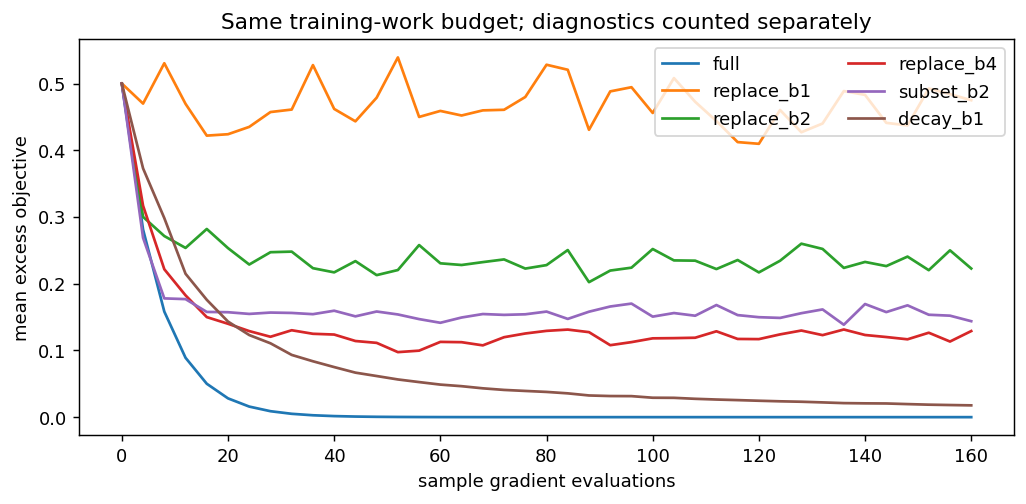

In [5]:
fig, ax = plt.subplots(figsize=(8,4))
for name in ['full','replace_b1','replace_b2','replace_b4','subset_b2','decay_b1']:
    c = [r for r in methods[name]['curve'] if r['sample_gradients']%4==0]
    ax.plot([r['sample_gradients'] for r in c],[r['mean_excess'] for r in c],label=name)
ax.set(xlabel='sample gradient evaluations',ylabel='mean excess objective',title='Same training-work budget; diagnostics counted separately')
ax.legend(ncol=2); fig.tight_layout(); show(fig); plt.close(fig)

## 5 均值误差与MSE
同一群运行中，平均参数接近最优并不意味着每一条运行都接近最优。

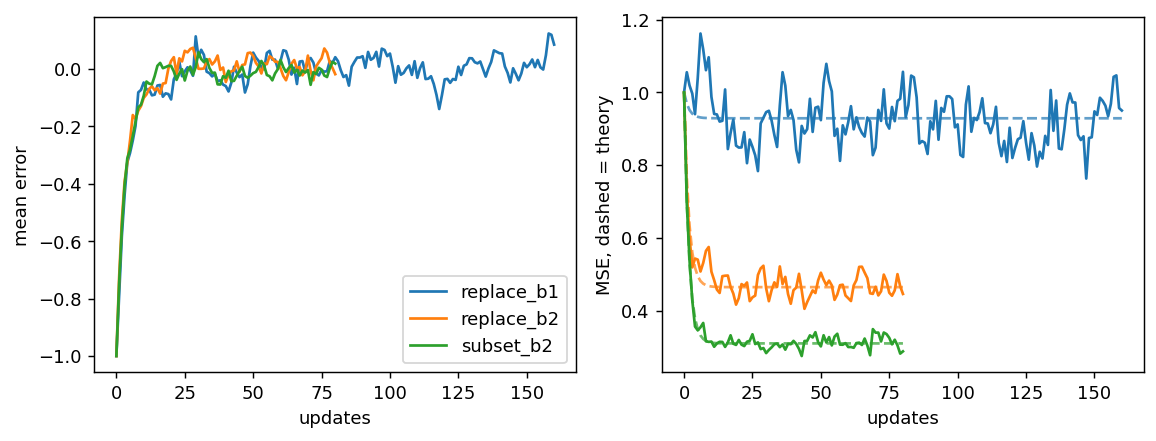

In [6]:
fig,axs=plt.subplots(1,2,figsize=(9,3.5))
for name in ['replace_b1','replace_b2','subset_b2']:
    c=methods[name]['curve'];t=[r['updates'] for r in c]
    axs[0].plot(t,[r['mean_error'] for r in c],label=name)
    line,=axs[1].plot(t,[r['mean_squared_error'] for r in c],label=name)
    axs[1].plot(t,[r['theory']['mean_squared_error'] for r in c],ls='--',alpha=.7,color=line.get_color())
axs[0].set(xlabel='updates',ylabel='mean error');axs[1].set(xlabel='updates',ylabel='MSE, dashed = theory');axs[0].legend();fig.tight_layout();show(fig);plt.close(fig)

## 6 分位带与均值标准误
左图画运行分布的中间80%；右图画均值±2个经验标准误，作为点态诊断，未作同时覆盖保证。

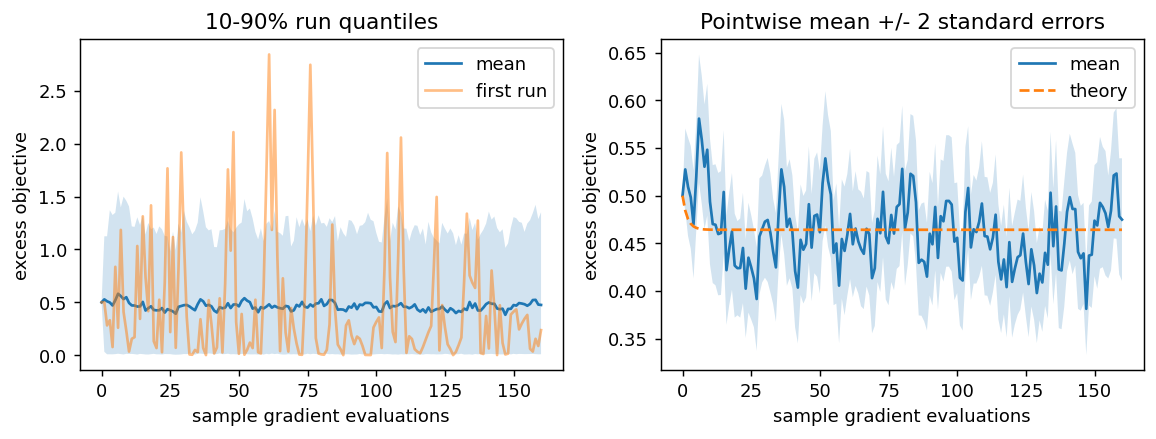

In [7]:
c=methods['replace_b1']['curve'];x=np.array([r['sample_gradients'] for r in c]);mean=np.array([r['mean_excess'] for r in c]);se=np.array([r['mean_excess_standard_error'] for r in c])
fig,axs=plt.subplots(1,2,figsize=(9,3.5))
axs[0].fill_between(x,[r['excess_q10'] for r in c],[r['excess_q90'] for r in c],alpha=.2);axs[0].plot(x,mean,label='mean');axs[0].plot(x,[r['first_run_excess'] for r in c],alpha=.5,label='first run')
axs[1].fill_between(x,mean-2*se,mean+2*se,alpha=.2);axs[1].plot(x,mean,label='mean');axs[1].plot(x,[r['theory']['mean_excess'] for r in c],ls='--',label='theory')
axs[0].set(title='10-90% run quantiles');axs[1].set(title='Pointwise mean +/- 2 standard errors')
for ax in axs:ax.set(xlabel='sample gradient evaluations',ylabel='excess objective');ax.legend()
fig.tight_layout();show(fig);plt.close(fig)

## 7 配对固定与递减计划
同一次重复使用相同索引。最终差值的标准误直接由配对差计算。

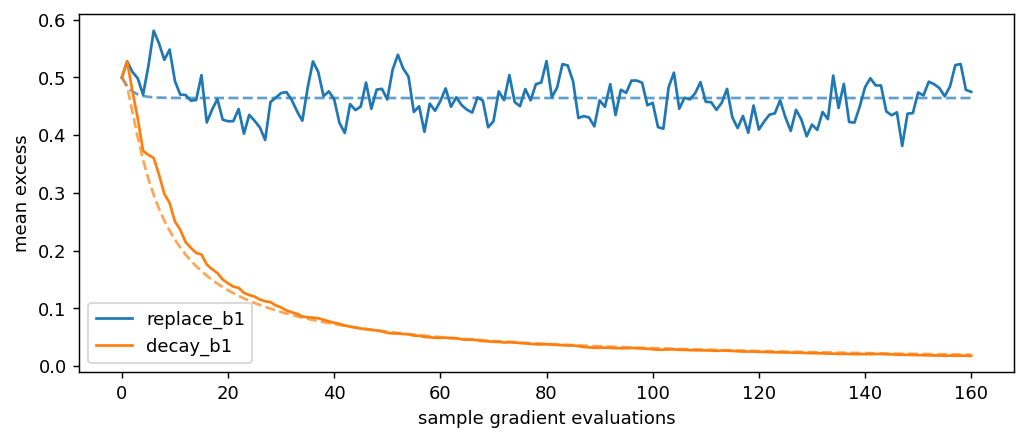

{'comparison': 'decay minus constant excess at same final cost, SAME sampled index stream', 'mean_difference': -0.4572772864892082, 'standard_error_of_paired_difference': 0.032204173130606105}


In [8]:
fig,ax=plt.subplots(figsize=(8,3.5))
for name in ['replace_b1','decay_b1']:
    c=methods[name]['curve'];line,=ax.plot([r['sample_gradients'] for r in c],[r['mean_excess'] for r in c],label=name)
    ax.plot([r['sample_gradients'] for r in c],[r['theory']['mean_excess'] for r in c],ls='--',alpha=.7,color=line.get_color())
ax.set(xlabel='sample gradient evaluations',ylabel='mean excess');ax.legend();fig.tight_layout();show(fig);plt.close(fig)
print(report['paired']['b1'])

## 8 最终参数分布
400条实际运行的终点，直方图不是理论密度。

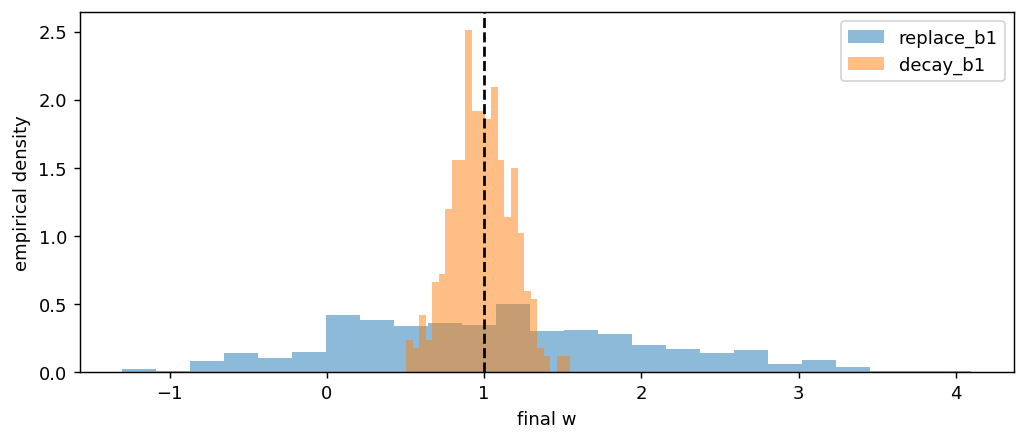

In [9]:
fig,ax=plt.subplots(figsize=(8,3.5))
for name in ['replace_b1','decay_b1']:
    ax.hist(methods[name]['final_parameters'],bins=25,alpha=.5,density=True,label=name)
ax.axvline(1,color='black',ls='--');ax.set(xlabel='final w',ylabel='empirical density');ax.legend();fig.tight_layout();show(fig);plt.close(fig)

## 9 顺序效应
每个点来自在不断变化的旧参数处重新计算的梯度。查看first_run_trace可逐步追溯。

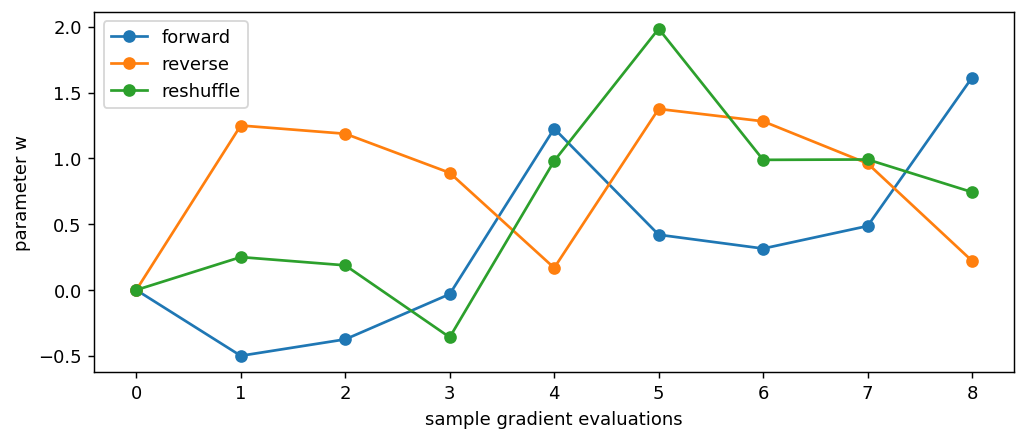

forward first epoch 157/128
reverse first epoch 43/256


In [10]:
fig,ax=plt.subplots(figsize=(8,3.5))
for name in ['forward','reverse','reshuffle']:
    c=methods[name]['curve'][:9];ax.plot([r['sample_gradients'] for r in c],[r['first_run_parameter'] for r in c],'o-',label=name)
ax.set(xlabel='sample gradient evaluations',ylabel='parameter w');ax.legend();fig.tight_layout();show(fig);plt.close(fig)
print('forward first epoch',F(methods['forward']['curve'][4]['first_run_parameter']))
print('reverse first epoch',F(methods['reverse']['curve'][4]['first_run_parameter']))

## 10 坏尾字段必须先失败
仅改内存中的副本。这里不改教学输入或旧输出文件。

In [11]:
import copy
bad_spec=copy.deepcopy(spec);bad_spec['batch_sizes']=[1,2,True]
old_rng=ex.make_rng
ex.make_rng=lambda *a: (_ for _ in ()).throw(RuntimeError('不应进入RNG'))
try:
    try:ex.run_experiment(y,bad_spec)
    except ValueError as err:print('预期拒绝:',str(err))
    else:raise RuntimeError('坏尾字段竟被接受')
finally:ex.make_rng=old_rng
print(report['importance'])

预期拒绝: batch must be bounded Python integer
{'probabilities': [0.125, 0.125, 0.25, 0.5], 'uncorrected_expectation': -2.5, 'corrected_expectation': -1.0, 'full_gradient': -1.0}


## 11 全报告校验与结论
不要仅比较一张曲线。最后验证矩分解、预算及两条完整数值路线；输出只写入本单元的运行结果目录。

In [12]:
for name,m in methods.items():
    assert m['sample_gradients_per_run'] <= spec['sample_gradient_budget']
    for r in m['curve']:
        assert abs(r['mean_squared_error']-r['variance_population']-r['mean_error']**2)<1e-10
out=ROOT/'notebook_results';out.mkdir(exist_ok=True)
(out/'report.json').write_bytes(ex.report_bytes(report))
print('完整报告写入成功，SHA256',hashlib.sha256(ex.report_bytes(report)).hexdigest())
print('分位带不是均值置信区间；同预算不等于同硬件耗时。')

完整报告写入成功，SHA256 f50c0a95f9d9682be90cc0c20cb82c78fcb395501c9516a6f641195395a5dacb
分位带不是均值置信区间；同预算不等于同硬件耗时。
